### Adaptive RAG

In [1]:
import os
from dotenv import load_dotenv
load_dotenv() ## aloading all the environment variable


os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [2]:
### Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# Set embeddings
embd = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=embd
)

retriever = vectorstore.as_retriever()

USER_AGENT environment variable not set, consider setting it to identify your requests.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
### Router

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web_search.
Respond with only one word: vectorstore or web_search."""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

question_router = route_prompt | llm | StrOutputParser()

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "}
    ).strip().lower()
)

web_search


In [42]:
print(question_router.invoke({"question": "What are the types of agent memory?"}).strip().lower())

vectorstore


In [43]:
### Retrieval Grader

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question.
If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.
It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
Respond with only one word: yes or no."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n{document}\n\nUser question: {question}"),
    ]
)

retrieval_grader = grade_prompt | llm | StrOutputParser()
question = "agent memory"
## context
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}).strip().lower())

yes


In [44]:
### Generate

from langchain_core.output_parsers import StrOutputParser

# Prompt
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are an assistant for question-answering tasks. Use the provided context to answer the question. If the answer is not in the context, say you do not know. Keep the answer concise.",
        ),
        (
            "human",
            "Question: {question}\n\nContext:\n{context}\n\nAnswer:",
        ),
    ]
)

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)


# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
print(generation)

Component Two: Memory

Types of Memory

Maximum Inner Product Search (MIPS)


In [45]:
### Hallucination Grader

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in or supported by a set of retrieved facts.
Respond with only one word: yes or no.
Yes means that the answer is grounded in or supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n{documents}\n\nLLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | llm | StrOutputParser()
hallucination_grader.invoke({"documents": format_docs(docs), "generation": generation}).strip().lower()

'yes'

In [46]:
### Answer Grader

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# Prompt
system = """You are a grader assessing whether an answer addresses or resolves a question.
Respond with only one word: yes or no.
Yes means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n{question}\n\nLLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | llm | StrOutputParser()
answer_grader.invoke({"question": question, "generation": generation}).strip().lower()

'no'

In [47]:
### Question Re-writer

# LLM
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

# Prompt
system = """You are a question re-writer that converts an input question into a better version optimized for vectorstore retrieval.
Return only the rewritten question."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question:\n\n{question}\n\nFormulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'"Agent memory capabilities"'

In [48]:
### Search

from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

In [49]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
        source: retrieval source
    """

    question: str
    generation: str
    documents: List[str]
    source: str

In [50]:
from langchain_core.documents import Document


def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question, "source": "vectorstore"}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]
    source = state["source"]

    # RAG generation
    generation = rag_chain.invoke({"context": format_docs(documents), "question": question})
    return {"documents": documents, "question": question, "generation": generation, "source": source}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]
    source = state["source"]

    # Score each doc
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.strip().lower()
        if grade.startswith("yes"):
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            continue
    return {"documents": filtered_docs, "question": question, "source": source}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    source = state["source"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question, "source": source}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)

    return {"documents": [web_results], "question": question, "source": "web_search"}


### Edges ###


def route_question(state):
    """
    Route question to web search or RAG.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE QUESTION---")
    question = state["question"]
    source = question_router.invoke({"question": question}).strip().lower()
    if source.startswith("web_search"):
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"
    elif source.startswith("vectorstore"):
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    filtered_documents = state["documents"]

    if not filtered_documents:
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"


def route_after_transform(state):
    """
    Route the transformed query back to the original retrieval source.

    Args:
        state (dict): The current graph state

    Returns:
        str: Next node to call
    """

    print("---ROUTE TRANSFORMED QUERY---")
    source = state["source"]

    if source == "web_search":
        print("---ROUTE TRANSFORMED QUERY TO WEB SEARCH---")
        return "web_search"

    print("---ROUTE TRANSFORMED QUERY TO RAG---")
    return "retrieve"


def handle_not_supported(state):
    """
    Handle unsupported generations before query transformation.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Unchanged state for downstream processing
    """

    print("---HANDLE NOT SUPPORTED---")
    return state


def handle_not_useful(state):
    """
    Handle grounded but unhelpful generations before query transformation.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Unchanged state for downstream processing
    """

    print("---HANDLE NOT USEFUL---")
    return state


def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    source = state["source"]

    score = hallucination_grader.invoke(
        {"documents": format_docs(documents), "generation": generation}
    )
    grade = score.strip().lower()

    # Check hallucination
    if grade.startswith("yes"):
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.strip().lower()
        if grade.startswith("yes"):
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, TRANSFORM QUERY---")
        return "not supported"

In [51]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("web_search", web_search)  # web search
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("handle_not_supported", handle_not_supported)
workflow.add_node("handle_not_useful", handle_not_useful)

# Build graph
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)
workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_conditional_edges(
    "transform_query",
    route_after_transform,
    {
        "web_search": "web_search",
        "retrieve": "retrieve",
    },
)
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "handle_not_supported",
        "useful": END,
        "not useful": "handle_not_useful",
    },
)
workflow.add_edge("handle_not_supported", "transform_query")
workflow.add_edge("handle_not_useful", "transform_query")

# Compile
app = workflow.compile()

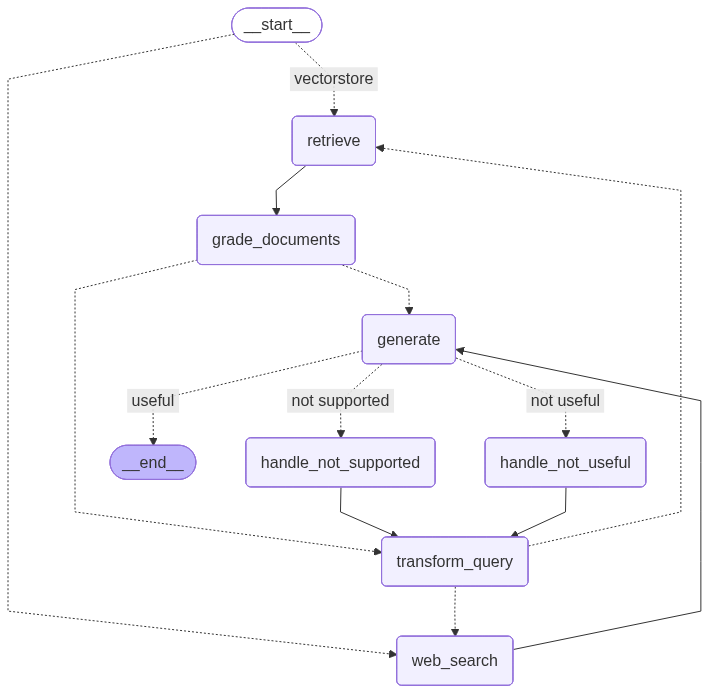

In [52]:
app

In [53]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subfield of artificial intelligence that gives computers the ability to learn without explicitly being programmed. It involves using algorithms to analyze and learn from large datasets, enabling machines to make predictions and decisions based on patterns and trends.',
 'documents': [Document(metadata={}, page_content='Glossary\n   v\n   t\n   e\n\nMachine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks "Task (computing)") without explicit instructions.( Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks "Neural network (machine learning)"), a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\n\nStatistics and mathematical optimisation (math

In [54]:
app.invoke({"question":"What is agent memory"})

---ROUTE QUESTION---
---ROUTE QUESTION TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION DOES NOT ADDRESS QUESTION---
---HANDLE NOT USEFUL---
---TRANSFORM QUERY---
---ROUTE TRANSFORMED QUERY---
---ROUTE TRANSFORMED QUERY TO RAG---
---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: GENERATE---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTIO

{'question': 'What is the definition of agent memory.',
 'generation': 'In the context of LLM-powered autonomous agents, agent memory refers to the component that enables the agent to retain and recall information over extended periods. It is divided into two types: \n\n1. Short-term memory: Utilizes in-context learning and is considered to be all the in-context learning (See Prompt Engineering) as utilizing short-term memory of the model to learn.\n2. Long-term memory: Provides the agent with the capability to retain and recall (infinite) information over extended periods, often by leveraging an external vector store and fast retrieval.',
 'documents': [Document(id='41280f40-d302-47da-8f28-0e2c69b3dcee', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, G